QSIND mra and natural domain layer (1D, 2D, 3D)

---

Kishore Kumar Tarafdar, 04Jul2025

In [1]:
pwd

'/data1/kishoretarafdar/src.port/multiresolution_kernels.v0/VolterraSys/nonlinear_kernels'

        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    

        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    # '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 48#16#32 #GB
select_a_gpu(gpus, gpu_id=1, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from TFDWT.DWT1DFB import DWT1D, IDWT1D
# from TFDWT.DWT2DFB import DWT2D, IDWT2D


2025-07-04 04:59:19.464248: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751585359.484661 1529360 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751585359.490986 1529360 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-04 04:59:19.511904: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 48 GB memory limit


I0000 00:00:1751585361.545623 1529360 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 49152 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:23:00.0, compute capability: 8.6


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

# QSIVolterraNDlayout (mother class)

In [3]:
import tensorflow as tf
import string

@tf.keras.utils.register_keras_serializable()
class QSIVolterraNDlayout(tf.keras.layers.Layer):
    """ QSI Volterra ND [1D, 2D, 3D] kernels in natural domain

        VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
    """
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters
        self.wave = wave
        if self.wave is None: self.mra = False
        else: self.mra = True

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.axes = list(range(1, len(input_shape) - 1))
        self.dim = self.axes[-1]
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        # kernel_shape = (self.L, self.channels, self.filters)
        kernel_shape = [self.L] * self.dim + [self.channels, self.filters]
        self.h = self.add_weight(
            # shape=(self.L, self.channels),
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel')
        super().build(input_shape)

    def _make_h2(self):
        ## make h2: ## Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
        if self.dim==1:
            h2 = tf.einsum('ico,jco->ijco', self.h, self.h)  # (L, L, channels)
        if self.dim==2:
            h2 = tf.einsum('ijco,klco->ijklco', self.h, self.h)  # (L, L, channels)
        elif self.dim==3:
            h2 = tf.einsum('ijkco,pqrco->ijkpqrco', self.h, self.h)  # (L, L, channels)
        else: raise NotImplementedError("Hardcoded einsum strings supported for dim=1,2,3")
        return h2
    
    def tf_pad_nd_volterra(self, h2, N, L, D):
        """
        Pad an ND Volterra kernel tensor from shape [L]*2D + [c, f] to [N]*2D + [c, f], using only TensorFlow ops.

        Args:
            h2: tf.Tensor, shape [L, ... L] (2D times), [c, f]
            N: int, target spatial size
            L: int, kernel spatial size
            D: int, number of spatial dimensions

        Returns:
            h2_padded: tf.Tensor, shape [N]*2D + [c, f]
        """
        pad = N - L
        t = h2
        for axis in range(2*D):  # pad all spatial axes (the first 2*D axes)
            # Compute the shape for the pad tensor to be appended at the end
            pad_shape_post = tf.concat([
                tf.shape(t)[:axis],
                [pad],
                tf.shape(t)[axis+1:]
            ], axis=0)
            pad_tensor_post = tf.zeros(pad_shape_post, dtype=t.dtype)
            t = tf.concat([t, pad_tensor_post], axis=axis)
            # No pad at the beginning (left), only at the end (right)
        return t

    def get_nd_shifted_h2(self, h2):
        """Create shifted h2 for vectorized trace convolution"""
        # h2: ([N]*D)*2 + [channels, filters]  (i.e., [N,...,N, N,...,N, c, f])
        # N: spatial size
        # D: number of spatial dimensions
        N = self.N
        D = self.dim

        # Output indices
        n = [tf.range(N) for _ in range(D)]
        k = [tf.range(N) for _ in range(D*2)]

        mesh = tf.meshgrid(*(n + k), indexing='ij')  # mesh of shape [N,...,N]*D + [N,...,N]*2D

        # For each spatial axis, build the shifted indices for both quadratic groups
        idx_list = []
        for d in range(D):
            n_d = mesh[d]
            k1_d = mesh[D + d]
            k2_d = mesh[D + D + d]
            idx_list.append((n_d - k1_d) % N)
        for d in range(D):
            n_d = mesh[d]
            k2_d = mesh[D + D + d]
            idx_list.append((n_d - k2_d) % N)

        idx = tf.stack(idx_list, axis=-1)  # shape: [N,...,N]*3D, 2D
        idx_flat = tf.reshape(idx, [-1, 2*D])
        gathered = tf.gather_nd(h2, idx_flat)
        output_shape = [N] * (3 * D) + [h2.shape[-2], h2.shape[-1]]
        gathered = tf.reshape(gathered, output_shape)
        return gathered   
        
    def get_einsum_strings(self, dim):
        """
        Returns einsum strings for quadratic Volterra layer, hardcoded for dim=1,2,3,
        matching the exact manual pattern.
        """
        if dim == 1:
            x2_eq = 'bic,bjc->bijc'
            y2_eq = 'ijkco,bjkc->bio'
        elif dim == 2:
            x2_eq = 'bijc,bklc->bijklc'
            y2_eq = 'ijklmnco, bklmnc->bijo'
        elif dim == 3:
            x2_eq = 'bijkc,bpqrc->bijkpqrc'
            y2_eq = 'ijkpqrstuco,bpqrstuc->bijko'
        else: raise NotImplementedError("Hardcoded einsum strings supported for dim=1,2,3")
        return x2_eq, y2_eq  

    def make_h2_shifted_kernel(self):
        ## make h2: ## Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)  
        self.h2 = self._make_h2()
  
        if self.dim in [1,2]:
            ## new update ND (tf.pad limitation!)
            # Pad to (N, N, channels)
            # paddings = [
            #     [0, self.N - self.L],
            #     [0, self.N - self.L],
            #     [0, 0],
            #     [0, 0]
            # ]       
            paddings = [[0, self.N - self.L] for _ in range(self.dim*2)]  # spatial dims
            paddings += [[0, 0], [0, 0]]  # in_channels, out_channels
            h2_padded = tf.pad(self.h2, paddings, mode='CONSTANT', constant_values=0)
        elif self.dim >=3: ## use custom padding if dim 3 or above
            h2_padded = self.tf_pad_nd_volterra(self.h2, self.N, self.L, self.dim)
        print('h2_padded', h2_padded.shape, h2_padded.dtype)
     
        h2_shifted = self.get_nd_shifted_h2(h2_padded)
        print('h2shifted', h2_shifted.shape)
        return h2_shifted     

    def call(self, x):
        pass 

    def _call_compute_in_natural_domain(self, x):
        # x_shape = x.shape  # [batch, N, ..., N, channels]
        # x2_eq, y2_eq = self.get_einsum_strings(self.dim)
        # print('str1 ', x2_eq, '\nstr2 ', y2_eq)
        # x2: (batch, N^dim, N^dim, channels)
        x2_eq, y2_eq = self.get_einsum_strings(self.dim)
        x2 = tf.einsum(x2_eq, x, x)
        h2_shifted = self.make_h2_shifted_kernel()
        # y2: (batch, N^dim, output_channels)
        y2 = tf.einsum(y2_eq, h2_shifted, x2)
        return y2    

    def get_filter(self):
        return self.h2

    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'wavelet': self.wave,
            'filters': self.filters,
            'mra': self.mra
        })
        return config

# QSIVolterraND (inherited)

        (natural newer) ND layer update with cases for [1,2] dim (with tf inbuilt)
        padding for dim 3 and above are custom made 
        einsum exprs coded upto 3dim

In [4]:
import tensorflow as tf
import string
      
@tf.keras.utils.register_keras_serializable()
class QSIVolterraND(QSIVolterraNDlayout):
    """ QSI Volterra ND [1D, 2D, 3D] kernels in natural domain

        VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
    --kkt@3Jul2025"""
    def __init__(self, filters=1, kernel_size=4, wave=None, **kwargs):
        super().__init__(filters=filters, kernel_size=kernel_size, wave=wave, **kwargs)        

    def call(self, x):
        return self._call_compute_in_natural_domain(x)  

        
if __name__ =='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
    ## Example
    # Functional model
    N, channels, filters = 4, 1, 1
    # input_shape = (N, channels)  # Replace N with the actual size of x            #1D
    input_shape = (N, N, channels)  # Replace N with the actual size of x         #2D
    # input_shape = (N, N, N, channels)  # Replace N with the actual size of x        #3D
    inputs = tf.keras.Input(shape=input_shape)
    H = QSIVolterraND(filters=filters)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 1D Random data
    # x = tf.random.normal((1, N, 1))
    # y = tf.random.normal((1, N, 1))
    ## 2D Random data
    x = tf.random.normal((1, N, N, 1))
    y = tf.random.normal((1, N, N, 1))
    ## 3D Random data
    # x = tf.random.normal((1, N, N, N, 1))
    # y = tf.random.normal((1, N, N, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(x, y, epochs=5, verbose=1)

    ## OR 
    model.predict(x)


"""
2D I/O
h2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 1, 1)
> (4, 4, 4, 4, 4, 4, 1, 1) (None, 4, 4, 4, 4, 1)

"""

2025-07-04 04:59:25.454949: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 48.00GiB (51539607552 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-07-04 04:59:25.455264: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 43.20GiB (46385643520 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-07-04 04:59:25.455516: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 38.88GiB (41747079168 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-07-04 04:59:25.455758: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 34.99GiB (37572370432 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-07-04 04:59:25.455977: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 31.49GiB (3381

h2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 1, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 4, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra_nd (QSIVolterraND) │ (None, 4, 4, 1)        │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
h2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 1, 1)
h2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step - loss: 0.6739
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.6684
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6631
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6578
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6527
h2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 1, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


"\n2D I/O\nh2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>\nh2shifted (4, 4, 4, 4, 4, 4, 1, 1)\n> (4, 4, 4, 4, 4, 4, 1, 1) (None, 4, 4, 4, 4, 1)\n\n"

# QSIVolterra2D (interited)

       QSI 2D MRA and natural kernel in one

In [5]:
import tensorflow as tf
# from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT2DFB import DWT2D, IDWT2D

@tf.keras.utils.register_keras_serializable()
class QSIVolterra2D(QSIVolterraNDlayout):
    """ QSI Volterra 2D I/O in wavelet and in natural domain

        VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
    --kkt@3Jul2025"""
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(filters=filters, kernel_size=kernel_size, wave=wave, **kwargs)
        # Add any other initialization you need here 
    
    def make_h2_shifted_mra_kernel(self):
        self.h2 = self._make_h2()
        h2_shifted = self.make_h2_shifted_kernel()        
        print('h2shifted', h2_shifted.shape)           
        shape = tf.shape(h2_shifted) # ij kl mn co 
        _ = tf.reshape(h2_shifted, [shape[0]*shape[1]*shape[2]*shape[3], shape[4], shape[5], shape[6]*shape[7]])
        _ = DWT2D(self.wave, clean=False)(_) #mn
        _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7]])
        _ = tf.reshape(_, [shape[0]*shape[1], shape[2], shape[3], shape[4]*shape[5]*shape[6]*shape[7]])
        _ = DWT2D(self.wave, clean=False)(_) #kl
        _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7]])
        _ = tf.reshape(_, [shape[0], shape[1], shape[2]*shape[3], shape[4]*shape[5]*shape[6]*shape[7]])
        _ = tf.transpose(_, perm=[2,0,1,3])
        _ = DWT2D(self.wave, clean=False)(_) #ij
        _ = tf.transpose(_, perm=[1,2,0,3])
        H = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7]])
            # return H
        # H = make_mra_kernel2(h2_shifted)
        print('H',H.shape)
        return H

    def call(self, x):
        self.x = x
        if self.mra==True: return self._call_compute_with_mra_kernel(x)   
        else: return self._call_compute_in_natural_domain(x)

    def _call_compute_with_mra_kernel(self, x):
        x2_eq, y2_eq = self.get_einsum_strings(self.dim)
        x2 = tf.einsum(x2_eq, x, x)  
        # self.x2 = tf.einsum('bijc,bklc->bijklc', x, x) 
        def dwt4(x2):
            shape = tf.shape(x2)
            _ = tf.reshape(x2, [shape[0]*shape[1]*shape[2], shape[3], shape[4], shape[5]])
            print('_',_.shape)
            _ = DWT2D(self.wave, clean=False)(_)
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5]])
            _ = tf.transpose(_, perm=[0,3,4,1,2,5])
            _ = tf.reshape(_, [shape[0]*shape[1]*shape[2], shape[3], shape[4], shape[5]])
            _ = DWT2D(self.wave, clean=False)(_)
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5]])
            return tf.transpose(_, perm=[0,3,4,1,2,5])
        α2 = dwt4(x2)
        print('α2', α2.shape)
        H = self.make_h2_shifted_mra_kernel()
        ## Fitlering
        β = tf.einsum('ijklmnco, bklmnc->bijo', H, α2)
        print('β', β.shape)

        # print(x2.shape, self.h2_shifted.shape)
        # y = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
        # y2 = self.idwt1(β)
        y2 = IDWT2D(self.wave, clean=False)(β)
        print('y2', y2.shape)
        return y2

    def sanity_check(self):
        return self._call_compute_with_mra_kernel(self.x), self._call_compute_in_natural_domain(self.x)  

        
if __name__ =='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"
    ## Example
    # Functional model
    N, channels, filters = 8, 1, 1
    input_shape = (N, N, channels)  # Replace N with the actual size of x       #2D
    inputs = tf.keras.Input(shape=input_shape)
    # Apply the custom layer to the inputs
    # H = QSIVolterra2D(filters=filters, wave=None)
    H = QSIVolterra2D(filters=filters, wave='db2')
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 2D Random data
    x = tf.random.normal((1, N, N, 1))
    y = tf.random.normal((1, N, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(x, y, epochs=5, verbose=1)    

_ (None, 8, 8, 1)
α2 (None, 8, 8, 8, 8, 1)
h2_padded (8, 8, 8, 8, 1, 1) <dtype: 'float32'>
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
H (8, 8, 8, 8, 8, 8, 1, 1)
β (None, 8, 8, 1)
y2 (None, 8, 8, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra2d (QSIVolterra2D)  │ (None, 8, 8, 1)        │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
_ (None, 8, 8, 1)
α2 (None, 8, 8, 8, 8, 1)
h2_padded (8, 8, 8, 8, 1, 1) <dtype: 'float32'>
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
H (8, 8, 8, 8, 8, 8, 1, 1)
β (None, 8, 8, 1)
y2 (None, 8, 8, 1)
_ (None, 8, 8, 1)
α2 (None, 8, 8, 8, 8, 1)
h2_padded (8, 8, 8, 8, 1, 1) <dtype: 'float32'>
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
H (8, 8, 8, 8, 8, 8, 1, 1)
β (None, 8, 8, 1)
y2 (None, 8, 8, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 3.8732
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 3.8293
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 3.7860
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3.7432
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 3.7009


In [6]:
_ = tf.random.normal((1, N, N, 1))
lay =  QSIVolterra2D(filters=filters, wave='db2')
y = lay(_)

_ (64, 8, 8, 1)
α2 (1, 8, 8, 8, 8, 1)
h2_padded (8, 8, 8, 8, 1, 1) <dtype: 'float32'>
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
H (8, 8, 8, 8, 8, 8, 1, 1)
β (1, 8, 8, 1)
y2 (1, 8, 8, 1)


In [7]:
y, ynat = lay.sanity_check()
y.shape, ynat.shape

_ (64, 8, 8, 1)
α2 (1, 8, 8, 8, 8, 1)
h2_padded (8, 8, 8, 8, 1, 1) <dtype: 'float32'>
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)
H (8, 8, 8, 8, 8, 8, 1, 1)
β (1, 8, 8, 1)
y2 (1, 8, 8, 1)
h2_padded (8, 8, 8, 8, 1, 1) <dtype: 'float32'>
h2shifted (8, 8, 8, 8, 8, 8, 1, 1)


(TensorShape([1, 8, 8, 1]), TensorShape([1, 8, 8, 1]))

(<Axes: >, <matplotlib.image.AxesImage at 0x7f7fdc337dd0>)

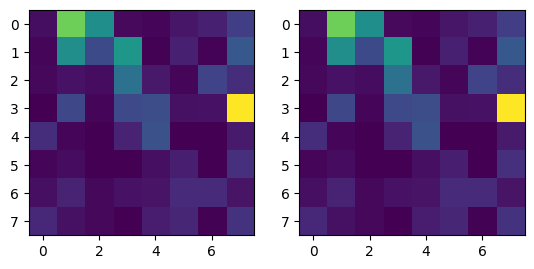

In [8]:
plt.subplot(121), plt.imshow(tf.squeeze(y)), 
plt.subplot(122), plt.imshow(tf.squeeze(ynat))

# QSIVolterra3D (inherited)


        QSI 3D MRA and natural domain kernel in one

In [9]:
import tensorflow as tf
# from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT3DFB import DWT3D, IDWT3D

@tf.keras.utils.register_keras_serializable()
class QSIVolterra3D(QSIVolterraNDlayout):
    """ QSI Volterra 3D I/O in wavelet and in natural domain

        VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
    --kkt@3Jul2025"""
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(filters=filters, kernel_size=kernel_size, wave=wave, **kwargs)
        # Add any other initialization you need here 
    
    def _make_h2_shifted_mra_kernel3(self):
        self.h2 = self._make_h2()
        h2_shifted = self.make_h2_shifted_kernel()      
          
        print('h2_shifted', h2_shifted.shape)
        shape = tf.shape(h2_shifted) # ijk pqr stu co, for example (4, 4, 4, 4, 4, 4, 1, 1)
        _ = tf.reshape(h2_shifted, [shape[0]*shape[1]*shape[2]*shape[3]*shape[4]*shape[5], shape[6], shape[7] , shape[8], shape[9]*shape[10]])
        _ = DWT3D(self.wave, clean=False)(_) #stu
        _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7], shape[8], shape[9],shape[10]])
        _ = tf.reshape(_,  [shape[0]*shape[1]*shape[2], shape[3], shape[4], shape[5], shape[6]*shape[7]*shape[8]*shape[9]*shape[10]])
        _ = DWT3D(self.wave, clean=False)(_) #pqr
        _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7], shape[8], shape[9],shape[10]])
        _ = tf.transpose(_, perm=[3,4,5, 0,1,2, 6,7,8,9,10])
        _ = tf.reshape(_, [shape[0]*shape[1]*shape[2], shape[3], shape[4], shape[5], shape[6]*shape[7]*shape[8]*shape[9]*shape[10]])
        _ = DWT3D(self.wave, clean=False)(_) #ijk
        _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7], shape[8], shape[9],shape[10]])
        H = tf.transpose(_, perm=[3,4,5, 0,1,2, 6,7,8,9,10])
        print('H',H.shape)
        return H

    def call(self, x):
        self.x = x
        if self.mra==True: return self._call_compute_with_mra_kernel3(x)   
        else: return self._call_compute_in_natural_domain(x)

    def _call_compute_with_mra_kernel3(self, x):
        # x: (batch, N, channels)
        # x2 = tf.einsum('bijkc,bpqrc->bijkpqrc', x, x)  # (batch, N, N, channels)
        # print('x2', x2.shape)
        x2_eq, y2_eq = self.get_einsum_strings(self.dim)
        x2 = tf.einsum(x2_eq, x, x) 
        def dwt6(x2): 
            shape = tf.shape(x2)  ## b ijk pqr c
            _ = tf.reshape(x2, [shape[0]*shape[1]*shape[2]*shape[3], shape[4], shape[5], shape[6], shape[7]])
            # print('_',_.shape)
            _ = DWT3D(self.wave, clean=False)(_)
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7]])
            _ = tf.transpose(_, perm=[0, 4,5,6, 1,2,3, 7])
            _ = tf.reshape(_, [shape[0]*shape[1]*shape[2]*shape[3], shape[4], shape[5], shape[6], shape[7]])
            _ = DWT3D(self.wave, clean=False)(_)
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7]])
            return tf.transpose(_, perm=[0, 4,5,6, 1,2,3, 7])
        α2 = dwt6(x2)
        print('α2', α2.shape)
        H = self._make_h2_shifted_mra_kernel3()
        ## Fitlering
        β = tf.einsum('ijkpqrstuco,bpqrstuc->bijko', H, α2)
        print('β', β.shape)

        # print(x2.shape, self.h2_shifted.shape)
        # y = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
        # y2 = self.idwt1(β)
        y2 = IDWT3D(self.wave, clean=False)(β)
        print('y2', y2.shape)
        return y2    

    def sanity_check(self):
        return self._call_compute_with_mra_kernel3(self.x), self._call_compute_in_natural_domain(self.x)  

        
if __name__ =='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"
    ## Example
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, N, N, channels)  # Replace N with the actual size of x       #2D
    inputs = tf.keras.Input(shape=input_shape)
    # Apply the custom layer to the inputs
    # H = QSIVolterra2D(filters=filters, wave=None)
    H = QSIVolterra3D(filters=filters, wave='db2')
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 2D Random data
    x = tf.random.normal((1, N, N, N, 1))
    y = tf.random.normal((1, N, N, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(x, y, epochs=5, verbose=1)    

α2 (None, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h2_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (None, 4, 4, 4, 1)
y2 (None, 4, 4, 4, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4, 4, 4, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra3d (QSIVolterra3D)  │ (None, 4, 4, 4, 1)     │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
α2 (None, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h2_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (None, 4, 4, 4, 1)
y2 (None, 4, 4, 4, 1)
α2 (None, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h2_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (None, 4, 4, 4, 1)
y2 (None, 4, 4, 4, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 3.8478
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3.7375
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.6314
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.5294
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.4314


In [10]:
_ = tf.random.normal((1, N, N, N, 1))
lay =  QSIVolterra3D(filters=filters, wave='db2')
y = lay(_)

α2 (1, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h2_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (1, 4, 4, 4, 1)
y2 (1, 4, 4, 4, 1)


In [11]:
y, ynat = lay.sanity_check()
y.shape, ynat.shape

α2 (1, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h2_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (1, 4, 4, 4, 1)
y2 (1, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)


(TensorShape([1, 4, 4, 4, 1]), TensorShape([1, 4, 4, 4, 1]))

In [12]:
import numpy as np
np.allclose(y, ynat, atol=1e-6)

True

In [72]:
# plt.subplot(121), plt.imshow(tf.squeeze(y)), 
# plt.subplot(122), plt.imshow(tf.squeeze(ynat))

----

END

<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>


        example inputs

In [4]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
# x = tf.constant([1.,2], dtype=tf.float32)

2025-07-03 21:19:22.815462: I external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1193] failed to allocate 48.00GiB (51539607552 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


In [ ]:
# h = tf.constant([1,2], dtype=tf.float32)

----

        the below layer is limited to 1D and 2D due to tf.pad limitations
        new ND layer is generalized above
        

In [ ]:
# generalized above for ND
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class QSIVolterra1D2D(tf.keras.layers.Layer):
    def __init__(self, filters=1, kernel_size=4, **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.axes = list(range(1, len(input_shape) - 1))
        self.dim = self.axes[-1]
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        # kernel_shape = (self.L, self.channels, self.filters)
        kernel_shape = [self.L] * self.dim + [self.channels, self.filters]
        h = self.add_weight(
            # shape=(self.L, self.channels),
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel'
        )
        
        if self.dim==1:
            h2 = tf.einsum('ico,jco->ijco', h, h)  # (L, L, channels)       
        elif self.dim==2:
            # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
            h2 = tf.einsum('ijco,klco->ijklco', h, h)  # (L, L, channels)
        elif self.dim==3:
            h2 = tf.einsum('ijkco,pqrco->ijkpqrco', h, h)  # (L, L, channels)
        self.h2 = h2
        
        # Pad to (N, N, channels)
        # paddings = [
        #     [0, self.N - self.L],
        #     [0, self.N - self.L],
        #     [0, 0],
        #     [0, 0]
        # ]
        
        ## new update ND (tf.pad limitation!)
        paddings = [[0, self.N - self.L] for _ in range(self.dim*2)]  # spatial dims
        paddings += [[0, 0], [0, 0]]  # in_channels, out_channels
        h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
        
        
        # def tf_pad_3d_volterra(h2, N, L):
        #     """
        #     h2: tf.Tensor of shape [L, L, L, L, L, L, c, f]
        #     N: target spatial size (input size)
        #     L: kernel spatial size (kernel size)
        #     Returns:
        #         h2_padded: [N, N, N, N, N, N, c, f]
        #     """
        #     pad = N - L
        #     # Pad each of the 6 spatial axes [0,5] with (0, pad)
        #     t = h2
        #     for axis in range(6):
        #         pad_shape_pre = tf.concat([tf.shape(t)[:axis], [0], tf.shape(t)[axis+1:]], axis=0)
        #         pad_shape_post = tf.concat([tf.shape(t)[:axis], [pad], tf.shape(t)[axis+1:]], axis=0)
        #         pad_tensor_pre = tf.zeros(pad_shape_pre, dtype=t.dtype)
        #         pad_tensor_post = tf.zeros(pad_shape_post, dtype=t.dtype)
        #         t = tf.concat([t, pad_tensor_post], axis=axis)
        #         # No pad at start (left), only at end (right)
        #     return t
        # h2_padded = tf_pad_3d_volterra(h2, self.N, self.L)
        print('h2_padded', h2_padded.shape, h2_padded.dtype)
        
        
        def get_nd_shifted_h2(h2):
            """Create shifted h2 for vectorized trace convolution"""
            # h2: ([N]*D)*2 + [channels, filters]  (i.e., [N,...,N, N,...,N, c, f])
            # N: spatial size
            # D: number of spatial dimensions
            N = self.N
            D = self.dim

            # Output indices
            n = [tf.range(N) for _ in range(D)]
            k = [tf.range(N) for _ in range(D*2)]

            mesh = tf.meshgrid(*(n + k), indexing='ij')  # mesh of shape [N,...,N]*D + [N,...,N]*2D

            # For each spatial axis, build the shifted indices for both quadratic groups
            idx_list = []
            for d in range(D):
                n_d = mesh[d]
                k1_d = mesh[D + d]
                k2_d = mesh[D + D + d]
                idx_list.append((n_d - k1_d) % N)
            for d in range(D):
                n_d = mesh[d]
                k2_d = mesh[D + D + d]
                idx_list.append((n_d - k2_d) % N)

            idx = tf.stack(idx_list, axis=-1)  # shape: [N,...,N]*3D, 2D
            idx_flat = tf.reshape(idx, [-1, 2*D])
            gathered = tf.gather_nd(h2, idx_flat)
            output_shape = [N] * (3 * D) + [h2.shape[-2], h2.shape[-1]]
            gathered = tf.reshape(gathered, output_shape)
            return gathered    
        
        self.h2_shifted = get_nd_shifted_h2(h2_padded)
        print('h2shifted', self.h2_shifted.shape)
        super().build(input_shape)


    def call(self, x):
        # x: (batch, N, channels)
        if self.dim==1:
            x2 = tf.einsum('bic,bjc->bijc', x, x)  # (batch, N, N, channels)
            # print(x2.shape, self.h2_shifted.shape)
            y2 = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
        
        elif self.dim==2:
            x2 = tf.einsum('bijc,bklc->bijklc', x, x)  # (batch, N, N, channels)
            print('>', self.h2_shifted.shape, x2.shape)
            y2 = tf.einsum('ijklmnco, bklmnc->bijo', self.h2_shifted, x2)
        
        elif self.dim==3:
            x2 = tf.einsum('bijkc,bpqrc->bijkpqrc', x, x)  # (batch, N, N, channels)
            print('>', self.h2_shifted.shape, x2.shape)
            y2 = tf.einsum('ijklmnopqcf, blmnopqc->bijkf', self.h2_shifted, x2)
            (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
        

        
        return y2
        
        

    def get_filter(self):
        return self.h2

        
if __name__ =='__main__':

    # Define input shape and build the model for summary
    N = 4
    input_shape = (N, N, 1)  # Replace N with the actual size of x
    inputs = tf.keras.Input(shape=input_shape)

    # Create an instance of the custom layer
    # h2 = np.array([[1, 2], 
    #           [1, 3]]).astype(np.float32)
    # H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
    # (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

    #conv1d_filters=32, conv1d_kernel_size=3, 
    #  conv2d_filters=32, conv2d_kernel_size=3)

    # Apply the custom layer to the inputs
    H = QSIVolterra1D2D()
    outputs = H(inputs)

    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Print the model summary
    model.summary()


"""
2D I/O
h2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 1, 1)
> (4, 4, 4, 4, 4, 4, 1, 1) (None, 4, 4, 4, 4, 1)

"""

h2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 1, 1)
> (4, 4, 4, 4, 4, 4, 1, 1) (None, 4, 4, 4, 4, 1)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 4, 4, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra_nd_15              │ (None, 4, 4, 1)        │            16 │
│ (QSIVolterraND)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

"\n2D I/O\nh2_padded (4, 4, 4, 4, 1, 1) <dtype: 'float32'>\nh2shifted (4, 4, 4, 4, 4, 4, 1, 1)\n> (4, 4, 4, 4, 4, 4, 1, 1) (None, 4, 4, 4, 4, 1)\n\n"

In [72]:
# ## working fine
# _1 = tf.random.uniform(shape=(4, 4, 4, 4, 4, 4, 1, 1))
# _2 = tf.random.uniform(shape=(4, 4, 4, 4, 1))
# tf.einsum('ijklmnco, klmnc->ijo',  _1, _2)

# ### working fine
# _1 = tf.random.uniform(shape=(4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1))
# _2 = tf.random.uniform(shape=(4, 4, 4, 4, 4, 4, 1))
# tf.einsum('ijklmnopqcf, lmnopqc->ijkf', _1, _2)

In [3]:

x.shape
# Instantiate the layer
# H = QSIVolterra1D(filters=filters)

# Call the layer
# ylay = H(x)

# print("Input shape:", x.shape)
# print("Output shape:", ylay.shape)
# print("Output (first batch example):\n", ylay[0].numpy())

TensorShape([1, 8, 8, 8, 1])

array([[[3.54110658e-01, 2.35990718e-01, 7.10745811e-01, 6.97146511e+00,
         3.17277193e-01, 2.16475144e-01, 5.38515449e-01, 4.37821925e-01],
        [7.42737576e-02, 6.79861784e-01, 9.06633213e-05, 1.25509346e+00,
         1.00782681e+00, 1.08746040e+00, 9.71544385e-02, 2.97682571e+00],
        [4.66733932e+00, 7.97335729e-02, 4.18937504e-01, 4.73733962e-01,
         5.64734459e-01, 1.95090637e-01, 1.34382534e+00, 8.94116223e-01],
        [3.11056692e-02, 1.32605862e-02, 3.45609576e-01, 5.19763112e-01,
         3.21166813e-01, 2.58988261e-01, 2.45265293e+00, 1.91582584e+00],
        [5.19296169e-01, 1.09700501e+00, 1.95955133e+00, 2.07962766e-02,
         2.06929818e-01, 4.28978726e-02, 4.52077913e+00, 2.03823060e-01],
        [2.24946991e-01, 1.39014482e+00, 1.95139945e-02, 2.84096628e-01,
         2.75750852e+00, 1.87736869e+00, 3.36526543e-01, 3.44792753e-03],
        [4.70414072e-01, 3.39512616e-01, 2.11387947e-02, 9.99090821e-02,
         4.17579412e-01, 2.06699431e-01, 5.84

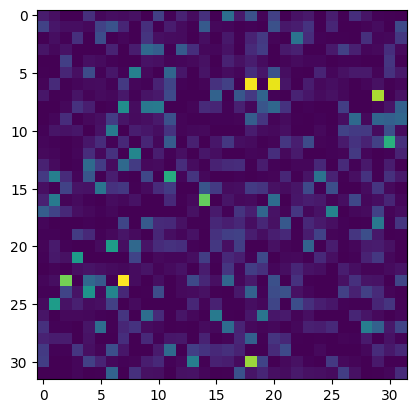

In [9]:
plt.imshow(ylay)

        check 1D

In [85]:
h2 = tf.squeeze(H.get_filter())
h2

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[ 0.00648597, -0.04849667,  0.04439661,  0.05051203],
       [-0.04849667,  0.36261752, -0.3319607 , -0.3776867 ],
       [ 0.04439661, -0.3319607 ,  0.30389574,  0.3457559 ],
       [ 0.05051203, -0.3776867 ,  0.3457559 ,  0.3933821 ]],
      dtype=float32)>

In [86]:
x.shape

TensorShape([1, 128, 1])

In [24]:
# x = x[0,:,0]

In [87]:
x = tf.squeeze(x)

h_padded tf.Tensor(
[[ 0.00648597 -0.04849667  0.04439661 ...  0.          0.
   0.        ]
 [-0.04849667  0.36261752 -0.3319607  ...  0.          0.
   0.        ]
 [ 0.04439661 -0.3319607   0.30389574 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]], shape=(128, 128), dtype=float32)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 1

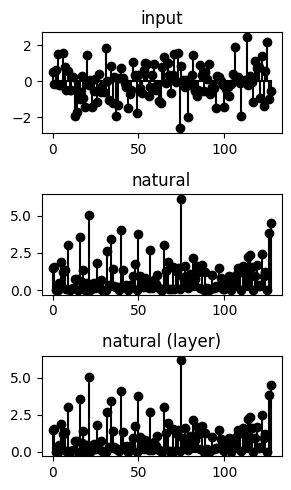

In [88]:


L = h2.shape[0] #filter length
# n = tf.range(L) 
Npoint = x.shape[0]
# Npoint = len(x)
paddings = [
        [0, Npoint - L],  # Depth dimension
        [0, Npoint - L]
        #    0,
        #    0,
        ]
# x
Npoint, paddings
h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
print('h_padded', h_padded)
h_padded.shape



x2 = tf.einsum('i,j->ij',x,x)
x2

### NAtural domain (alternative)
# q2 = tf.einsum('ijk,jk->i', h_columns_shifted, x2) ## faster
# slower version 
import numpy as np
def compute_q2(x2, h2):
    N = x2.shape[0]
    q2 = np.zeros(N).astype(float)
    for n in range(N):
        q2[n] = np.sum(h2 * x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)])
        print(x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)].shape)
    return q2

q2 = compute_q2(x2.numpy(),h_padded.numpy())
q2

plt.figure(figsize=(3,5))
plt.subplot(3,1,1), plt.stem(tf.squeeze(x).numpy(),'k', basefmt="k"), plt.title(f'input')
plt.subplot(3,1,2), plt.stem(tf.squeeze(q2).numpy(),'k', basefmt="k"), plt.title(f'natural')
# plt.subplot(3,1,3), plt.stem(tf.squeeze(y2).numpy(),'k', basefmt="k"), plt.title(f'Volterra (haar)')
plt.subplot(3,1,3), plt.stem(tf.squeeze(ylay).numpy(),'k', basefmt="k"), plt.title(f'natural (layer)')

plt.tight_layout()

In [89]:
np.allclose(q2, ylay, atol=1e-7)

True

In [ ]:
1

In [ ]:

# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)
# L = h.shape[0] #filter length
# # n = tf.range(L) 
# Npoint = x.shape[0]
# # Npoint = len(x)
# paddings = [
#         [0, Npoint - L],  # Depth dimension
#         [0, Npoint - L]
#         #    0,
#         #    0,
#         ]
# # x
# Npoint, paddings
# h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
# print('h_padded', h_padded)
# h_padded.shape

# ## creating h[n-k1,n-k2]
# N = Npoint
# n = tf.range(N)
# # Create circular indices for all possible shifts
# # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
# row_indices = tf.math.mod(n[:, tf.newaxis] - n, N)
# rows_shifted = tf.gather(h_padded, row_indices, axis=0)         # [N, N, N]
# rows_shifted
# h_columns_shifted = tf.gather(rows_shifted, row_indices,   # [N, N, N]
#                                 axis=2, batch_dims=1)
# h_columns_shifted, h_columns_shifted.shape




# _ = tf.expand_dims(tf.cast(h_columns_shifted, dtype=tf.float32), axis=-1)
# h_init = DWT2D(wave, clean=False)(_)
# print(tf.squeeze(h_init))

# H = tf.expand_dims(
#     tf.transpose(
#         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
#         perm=[1,0,2]),axis=-1)
# H[:,:,:,0]

# x2 = tf.einsum('i,j->ij',x,x)
# x2

# α2 = DWT2D(wave, clean=False)(tf.expand_dims(tf.expand_dims(x2, axis=-1),axis=0))
# α2.shape, tf.squeeze(α2)


# beta = tf.expand_dims(
#     tf.expand_dims(
#         tf.stack(
#             [tf.reduce_sum(H[k:k+1,:,:,:] * α2) for k in range(H.shape[0])]
#             ), axis=-1),axis=0)
# beta

# y2 = IDWT1D(wave, clean=False)(beta)
# y2



In [ ]:
# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)

In [ ]:

        
        ## OK (todo: check if values are matching)
        # def get_2d_shifted_h2(h2):
        #     # h2: (N, N, N, N, channels, filters)
        #     N = self.N
        #     n1 = tf.range(N)
        #     n2 = tf.range(N)
        #     k1 = tf.range(N)
        #     k2 = tf.range(N)
        #     k3 = tf.range(N)
        #     k4 = tf.range(N)
        #     n1g, n2g, k1g, k2g, k3g, k4g = tf.meshgrid(n1, n2, k1, k2, k3, k4, indexing='ij')

        #     i1 = (n1g - k1g) % N
        #     i2 = (n2g - k2g) % N
        #     j1 = (n1g - k3g) % N
        #     j2 = (n2g - k4g) % N

        #     idx = tf.stack([i1, i2, j1, j2], axis=-1)  # (N,N,N,N,N,N,4)
        #     idx_flat = tf.reshape(idx, [-1, 4])        # (N**6, 4)

        #     # THE FIX: Gather directly from h2, NO RESHAPE!
        #     gathered = tf.gather_nd(h2, idx_flat)      # (N**6, channels, filters)
        #     gathered = tf.reshape(gathered, [N, N, N, N, N, N, h2.shape[-2], h2.shape[-1]])  # (n1, n2, k1, k2, k3, k4, c, f)

        #     return gathered

In [ ]:
    # def call(self, x):
    #     # x: (batch, N, channels)
    #     if self.dim==1:
    #         x2 = tf.einsum('bic,bjc->bijc', x, x)  # (batch, N, N, channels)
    #         # print(x2.shape, self.h2_shifted.shape)
    #         y2 = tf.einsum('ijkco,bjkc->bio', self.h2_shifted, x2)
        
    #     elif self.dim==2:
    #         x2 = tf.einsum('bijc,bklc->bijklc', x, x)  # (batch, N, N, channels)
    #         print('>', self.h2_shifted.shape, x2.shape)
    #         y2 = tf.einsum('ijklmnco, bklmnc->bijo', self.h2_shifted, x2)
        
    #     elif self.dim==3:
    #         x2 = tf.einsum('bijkc,bpqrc->bijkpqrc', x, x)  # (batch, N, N, channels)
    #         print('>', self.h2_shifted.shape, x2.shape)
    #         y2 = tf.einsum('ijklmnopqcf, blmnopqc->bijkf', self.h2_shifted, x2)        
    #     return y2
    
    

In [ ]:
 # def einsum_string_quadratic_volterra(dim):
        #     letters = string.ascii_lowercase
        #     idx1 = letters[:dim]
        #     idx2 = letters[dim:2*dim]
        #     # Only one 'c' and one 'o' in the output!
        #     eq = f'{idx1}yz,{idx2}yz->{idx1}{idx2}yz'
        #     return eq
        # eq = einsum_string_quadratic_volterra(self.dim)
        # self.h2 = tf.einsum(eq, h, h)
        # self.h2 = nd_volterra_outer(h, self.dim)        


In [ ]:



        
        # def tf_pad_3d_volterra(h2, N, L):
        #     """
        #     h2: tf.Tensor of shape [L, L, L, L, L, L, c, f]
        #     N: target spatial size (input size)
        #     L: kernel spatial size (kernel size)
        #     Returns:
        #         h2_padded: [N, N, N, N, N, N, c, f]
        #     """
        #     pad = N - L
        #     # Pad each of the 6 spatial axes [0,5] with (0, pad)
        #     t = h2
        #     for axis in range(6):
        #         pad_shape_pre = tf.concat([tf.shape(t)[:axis], [0], tf.shape(t)[axis+1:]], axis=0)
        #         pad_shape_post = tf.concat([tf.shape(t)[:axis], [pad], tf.shape(t)[axis+1:]], axis=0)
        #         pad_tensor_pre = tf.zeros(pad_shape_pre, dtype=t.dtype)
        #         pad_tensor_post = tf.zeros(pad_shape_post, dtype=t.dtype)
        #         t = tf.concat([t, pad_tensor_post], axis=axis)
        #         # No pad at start (left), only at end (right)
        #     return t
        # h2_padded = tf_pad_3d_volterra(h2, self.N, self.L)
        # print('h2_padded', h2_padded.shape, h2_padded.dtype)